<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Nivel_Estres.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# 1. Definición del dataset original
data = {
    'Sueño': ['Poco', 'Poco', 'Poco', 'Suficiente', 'Suficiente', 'Suficiente', 'Poco', 'Suficiente'],
    'Ejercicio': ['No', 'No', 'Sí', 'No', 'Sí', 'Sí', 'Sí', 'No'],
    'Carga_Tareas': ['Alta', 'Normal', 'Alta', 'Alta', 'Normal', 'Alta', 'Normal', 'Normal'],
    'Estrés': ['Sí', 'Sí', 'Sí', 'Sí', 'No', 'No', 'No', 'No']
}

df= pd.DataFrame(data)
df

,Sueño,Ejercicio,Carga_Tareas,Estrés
0,Poco,No,Alta,Sí
1,Poco,No,Normal,Sí
2,Poco,Sí,Alta,Sí
3,Suficiente,No,Alta,Sí
4,Suficiente,Sí,Normal,No
5,Suficiente,Sí,Alta,No
6,Poco,Sí,Normal,No
7,Suficiente,No,Normal,No


In [12]:
#Preprocesamiento de datos
le = LabelEncoder()

df_encoded = df.copy()
encoders = {}

for columna in ["Sueño", "Ejercicio", "Carga_Tareas", "Estrés"]:
    encoders[columna] = LabelEncoder()
    df_encoded[columna] = encoders[columna].fit_transform(df[columna])

df_encoded
#

,Sueño,Ejercicio,Carga_Tareas,Estrés
0,0,0,0,1
1,0,0,1,1
2,0,1,0,1
3,1,0,0,1
4,1,1,1,0
5,1,1,0,0
6,0,1,1,0
7,1,0,1,0


In [13]:
#3 Separar features y variable objetivo
atributos = ["Sueño", "Ejercicio", "Carga_Tareas"]
X = df_encoded[atributos]
y = df_encoded["Estrés"]

In [14]:
#4 Entrenar el arbol con entropia (equivalente a id3)

modelo = DecisionTreeClassifier(
    criterion="entropy", #usa entropia como id3
    random_state=123
)
modelo.fit(X, y)

print(f"Profundidad del arbol: {modelo.get_depth()}")
print(f"Numero de hojas: {modelo.get_n_leaves()}")

Profundidad del arbol: 3
Numero de hojas: 6


In [15]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=atributos
).sort_values(ascending=False)

for atributo, valor in importancias.items():
  print(f" {atributo}: {valor:.4f}")
  print()

 Sueño: 0.4056

 Ejercicio: 0.4056

 Carga_Tareas: 0.1887



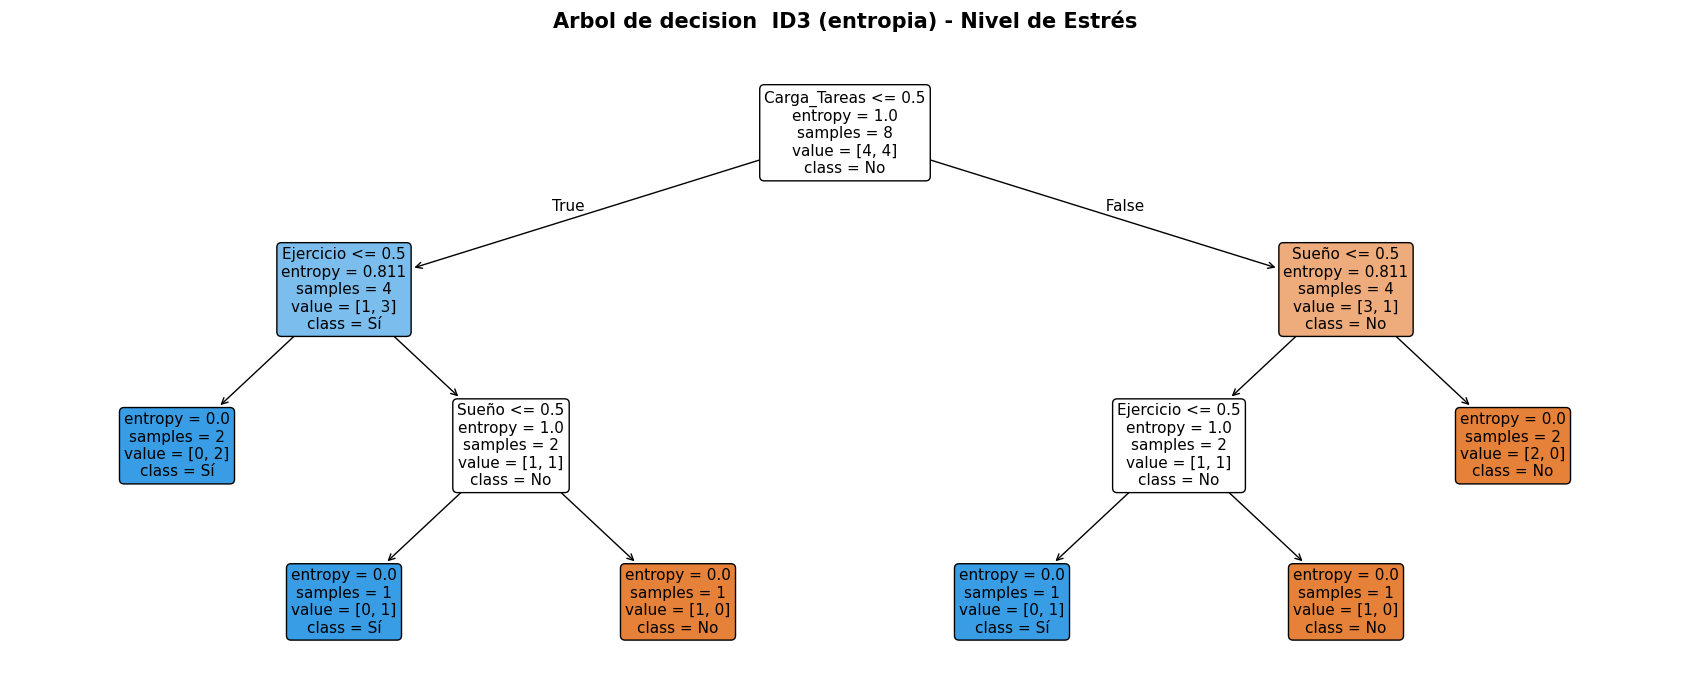

In [16]:
#Grafica 1: Arbol de decision con plot_free

fig1, ax1 = plt.subplots(figsize=(17, 7))
plot_tree(
    modelo,
    feature_names=atributos,
    class_names=encoders["Estrés"].classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax1,
    impurity=True,
    proportion=False
)

ax1.set_title(
    "Arbol de decision  ID3 (entropia) - Nivel de Estrés",
    fontsize=15,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()